In [2]:
import cv2
from matplotlib import pyplot as plt
import random
from scipy.ndimage import grey_dilation
import numpy as np

In [3]:
img0 = cv2.imread("../dataset_images/2/train_img_idx0000_label_0_id73_task2.png", 0)

In [4]:
def crop_black_columns(img):
    """
    Remove columns tah are completely black (all zeros)
    """
    mask = ~(img == 0).all(axis=0)
    no_black_columns = img[:, mask]
    return no_black_columns

def restore_full_width(img, cropped_img):
    """
    Restore the width of the original image by filling the removed columns.
    If fill_value is None, the cropped image will be repeated (tiled) horizontally.
    Otherwise, the remaining columns are filled with the specified value (e.g., 255 for white).
    """
    full_h, full_w = img.shape
    reduced_h, reduced_w = cropped_img.shape
    n_copies = int(np.ceil(full_w / reduced_w))
    tiled = np.tile(cropped_img, (1, n_copies))[:, :full_w]
    return tiled

def clean_and_refill(img):
    """
    Complete pipeline: remove black columns and restore width.
    If fill_value is None, repeats the cropped image to fill the width.
    If fill_value is specified (e.g., 255), fills the removed area with that value.
    """
    cropped_img = crop_black_columns(img)
    final_result = restore_full_width(img, cropped_img)
    return final_result

In [5]:
def apply_saltpepper(raw_img):
    img = raw_img.copy()

    # Getting the dimensions of the image
    row , col = img.shape
    
    # Randomly pick some pixels in the
    # image for coloring them white
    # Pick a random number between 300 and 10000
    number_of_pixels = random.randint(300, 10000)
    for i in range(number_of_pixels):
      
        # Pick a random y coordinate
        y_coord=random.randint(0, row - 1)
        
        # Pick a random x coordinate
        x_coord=random.randint(0, col - 1)
        
        # Color that pixel to white
        img[y_coord][x_coord] = 255
        
    # Randomly pick some pixels in
    # the image for coloring them black
    # Pick a random number between 300 and 10000
    number_of_pixels = random.randint(300 , 10000)
    for i in range(number_of_pixels):
      
        # Pick a random y coordinate
        y_coord=random.randint(0, row - 1)
        
        # Pick a random x coordinate
        x_coord=random.randint(0, col - 1)
        
        # Color that pixel to black
        img[y_coord][x_coord] = 0
        
    return img

In [6]:
def shear(img, sh_factor):
    if sh_factor == 0.0: return img

    (h, w) = img.shape
    matrix = np.float32([
        [1, sh_factor * 2, 0],
        [0, 1, 0]
    ])
    new_width = w + int(sh_factor * h)
    return cv2.warpAffine(img, matrix, (new_width, h))

def shear2(img, sh_factor):
    if sh_factor == 0.0:
        return img

    h, w = img.shape

    # Desplazamiento máximo
    dx = abs(sh_factor) * h
    new_width = int(w + dx)

    # Compensación si el shear es negativo
    tx = dx if sh_factor < 0 else 0

    matrix = np.float32([
        [1, sh_factor, tx],
        [0, 1, 0]
    ])

    return cv2.warpAffine(
        img,
        matrix,
        (new_width, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )


def crop(img, padding=2):
        img_copy = img
        contours, hierarchy = cv2.findContours(img_copy,  cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        if len(contours) > 0: 
            x, y, w, h = cv2.boundingRect(np.concatenate(contours))
            return_img = img_copy[max(0, y - padding): y+h + padding, max(0, x - padding): x+w + padding]
            return return_img
        return img_copy

def crop_to_content(img, bg_color):
    """
    Recorta la imagen al bounding box del contenido
    """
    # Contenido = todo lo que no sea fondo
    mask = img != bg_color

    # Seguridad: por si no hay contenido
    if not np.any(mask):
        return img

    ys, xs = np.where(mask)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()

    return img[y_min:y_max+1, x_min:x_max+1]

def rotate(img, angle):
    if angle == 0:
        return img
    
    padding = 200

    h, w = img.shape[:2]
    center = ((w) // 2, (h) // 2)

    canvas = np.zeros((h + padding, w + padding), dtype=img.dtype)

    hc, wc = canvas.shape[:2]

    canvas[(padding // 2):(padding//2)+h, (padding // 2):(padding//2)+w] = img


    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_img = cv2.warpAffine(canvas, matrix, (wc, hc))

    cropped = crop_to_content(rotated_img, bg_color=0)

    resized = cv2.resize(cropped, (w, h), interpolation=cv2.INTER_AREA)

    return resized

In [7]:
sp_img0 = apply_saltpepper(img0)

In [8]:
# Elemento estructurante 3x3
kernel = np.ones((3, 3))

# Dilatación
dimg = grey_dilation(img0, footprint=kernel)

In [9]:
gimg = cv2.GaussianBlur(img0, (15, 15), 0)

In [31]:
shear_img = shear(img0, 0.3)

In [32]:
rotated = rotate(
    img0,
    angle=5,
)

In [33]:
cv2.imwrite("img0.png", img0)
cv2.imwrite("sp_img0.png", sp_img0)
cv2.imwrite("dimg.png", dimg)
cv2.imwrite("gimg.png", gimg)
cv2.imwrite("shear_img.png", shear_img)
cv2.imwrite("rotate_img.png", rotated)

True

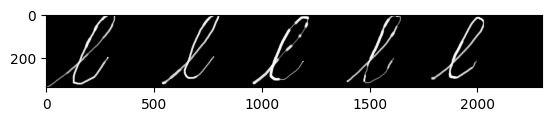

In [61]:
plt.imshow(dimg, cmap="gray")
plt.show()

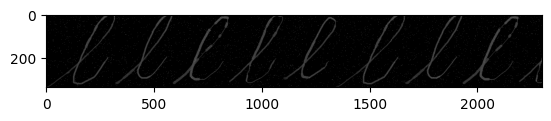

In [ ]:
plt.imshow(sp_img0, cmap="gray")
plt.show()